# **PRÁCTICA 2**

##### **Iván Ciller López, 100522245**
##### **Mohamed Rida Chahdaoui Moujib, 100522202**

## **APARTADO 1: CODIFICACIÓN DE VARIABLES**

Para comenzar con la práctica, empezamos viendo los distintos valores posibles para **Color** y **Spectral_Class**:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Fijamos la semilla
np.random.seed(100522245)  # Semilla con NIA

# Cargamos los datos
df = pd.read_csv('stars_data.csv')

# Ver valores únicos y cuántos hay de cada uno en la Clase Espectral
print("--- Recuento de Clase Espectral ---")
print(df['Spectral_Class'].value_counts())

print("\n--- Recuento de Colores ---")
# Ver valores únicos de Color
print(df['Color'].value_counts())

--- Recuento de Clase Espectral ---
Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

--- Recuento de Colores ---
Color
Red                   112
Blue                   56
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Blue white              4
Yellowish White         3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Yellowish               1
Orange-Red              1
Blue-White              1
Name: count, dtype: int64


Observamos que en **Spectral_Class** los valores son los esperados y, a priori, no hay nada que modificar (salvo convertirlos en número). No obstante, en **Color** podemos ver que hay colores que son los mismos pero están escritos de manera diferente, por lo que el algoritmo los tomará como colores distintos, como por ejemplo *Blue-white*, *Blue White*, *Blue white* y *Blue-White*, que son el mismo color pero difieren en mayúsculas, minúsculas y guiones. Por ello, a continuación abordaremos este problema poniendo todos los colores en un formato común:


In [2]:
# Normalización inicial de Color: quitamos espacios raros, pasamos a minúsculas y quitamos guiones
df['Color'] = df['Color'].str.lower().str.replace('-', ' ').str.strip()

# Hacemos un diccionario de corrección (mapeo de nombres feos a nombres limpios)
# Incluimos todas las variantes obtenidas en value_counts y les asignamos una común
limpieza_colores = {
    'red': 'red',
    'blue': 'blue',
    'blue white': 'blue white',
    'blue-white': 'blue white',
    'yellow-white': 'yellow white',
    'white yellow': 'yellow white',
    'yellowish white': 'yellow white',
    'white': 'white',
    'whitish': 'white',
    'yellowish': 'yellow',
    'orange': 'orange',
    'orange red': 'orange red',
    'pale yellow orange': 'pale yellow orange'
}

# Aplicamos la limpieza usando .replace() para no borrar los que ya están bien
df['Color'] = df['Color'].replace(limpieza_colores)

# Comprobamos que no se repiten datos y todo está como esperábamos
print("--- Clase Espectral (Limpia) ---")
print(df['Spectral_Class'].value_counts())

print("\n--- Colores (Limpios y agrupados) ---")
print(df['Color'].value_counts())

# Verificamos si hay algún valor nulo después de la limpieza
if df[['Color', 'Spectral_Class']].isnull().values.any():
    print("\nHay valores nulos")
else:
    print("\nNo hay valores nulos")

--- Clase Espectral (Limpia) ---
Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

--- Colores (Limpios y agrupados) ---
Color
red                   112
blue                   56
blue white             41
white                  12
yellow white           12
yellow                  3
orange                  2
pale yellow orange      1
orange red              1
Name: count, dtype: int64

No hay valores nulos


Como podemos observar, hemos conseguido poner todos los colores en un formato común, que consiste en que todos los colores estén en minúscula y sin guiones. Esto lo logramos usando **lower** para las minúsculas, **replace** para sustituir los guiones por espacios y **strip** por si hubiese algún espacio raro en los nombres. A continuación, creamos un diccionario para renombrar a los colores y usamos **replace** para sustituir los colores por su nuevo nombre. Finalmente, comprobamos que todo está correctamente hecho y comprobamos si han aparecido nulos (no han aparecido). Ahora debemos llevar a cabo la **codificación ordinal** (importante hacerla antes de **PCA**, pues este solo entiende de números):

In [3]:
# Definimos orden lógico para color de menor a mayor temperatura/energía
# Para ello, nos fijamos en la tabla del enunciado y las relaciones color-temperatura
orden_color = {
    'red': 0,
    'orange red': 1, 
    'orange': 2, 
    'pale yellow orange': 3, 
    'yellow': 4, 
    'white': 5,            
    'yellow white': 6,     
    'blue white': 7, 
    'blue': 8
}

# Definimos orden lógico para spectral_class de menor a mayor temperatura/energía
# Para ello, nos fijamos en la secuencia del enunciado y la mención de que O es la más caliente y M la más fría
orden_espectral = {
    'M': 0, 
    'K': 1, 
    'G': 2, 
    'F': 3, 
    'A': 4, 
    'B': 5, 
    'O': 6
}

# Aplicamos el mapeo para crear las columnas numéricas
df['Rango_Color'] = df['Color'].map(orden_color)
df['Rango_Espectral'] = df['Spectral_Class'].map(orden_espectral)


# Comprobamos que no se repiten datos y todo está como esperábamos
print("--- Clase Espectral (Numerada) ---")
print(df['Rango_Espectral'].value_counts())

print("\n--- Colores (Numerados) ---")
print(df['Rango_Color'].value_counts())

# Verificación final de nulos
print("Nulos en Rango_Color:", df['Rango_Color'].isnull().sum())
print("Nulos en Rango_Espectral:", df['Rango_Espectral'].isnull().sum())

--- Clase Espectral (Numerada) ---
Rango_Espectral
0    111
5     46
6     40
4     19
3     17
1      6
2      1
Name: count, dtype: int64

--- Colores (Numerados) ---
Rango_Color
0    112
8     56
7     41
5     12
6     12
4      3
2      2
3      1
1      1
Name: count, dtype: int64
Nulos en Rango_Color: 0
Nulos en Rango_Espectral: 0


Para la **codificación ordinal** comenzamos escribiendo dos diccionarios, uno para **Color** y otro para **Spectral_Class**. Ambas columnas son ordinales, pues sus atributos se pueden ordenar en función de la temperatura (es decir, si son más calientes o más fríos). Para ello, observamos la tabla dada en el enunciado y vemos que en **Color**, *red* es el más frío y *yellow white* es el más caliente. Debido a que faltan colores, nos informamos sobre los colores que suelen ser más calientes en tema de estrellas y vimos que el más caliente era *blue*. Para otros colores fuimos construyendo la jerarquía siguiendo el siguiente razonamiento: por ejemplo, *orange* es más frío que *yellow* por lo que *pale yellow orange* está entre ellos en la escala. Para la codificación de **Spectral_Class** nos fijamos nuevamente en el enunciado, que dice que este atributo sigue una secuencia determinada, siendo **O** la más caliente y **M** la más fría, por lo que ordenamos los distintos valores siguiendo el orden de la secuencia dada en el enunciado. Finalmente, comprobamos que todo está como esperábamos y verificamos que no existen nulos. 

A continuación veremos si el resto de atributos necesitan preprocesado:

In [5]:
# Lista de atributos numéricos originales
atributos_restantes = ['Temperature', 'L', 'R', 'A_M']

print("=== ANÁLISIS DE ATRIBUTOS RESTANTES ===")

for col in atributos_restantes:
    print(f"\n--- Columna: {col} ---")
    
    # Comprobamos nulos en esta columna
    nulos = df[col].isnull().sum()
    print(f"Valores nulos: {nulos}")
    
    # Obtenemos los distintos valores
    print(df[col].value_counts())
    
    # Vemos el rango (Mínimo y Máximo)
    # Útil para detectar si hay algún "0" que no tenga sentido
    print(f"Rango: [{df[col].min()} , {df[col].max()}]")

print("\n" + "="*30)

# Verificación global de nulos
if df.isnull().values.any():
    print("Hay nulos")
else:
    print("No hay nulos")

=== ANÁLISIS DE ATRIBUTOS RESTANTES ===

--- Columna: Temperature ---
Valores nulos: 0
Temperature
3600     3
2600     2
2650     2
3625     2
3450     2
        ..
38940    1
30839    1
8829     1
9235     1
37882    1
Name: count, Length: 228, dtype: int64
Rango: [1939 , 40000]

--- Columna: L ---
Valores nulos: 0
L
200000.00000    5
0.00067         3
0.00014         3
0.00098         3
0.00240         2
               ..
374830.00000    1
834042.00000    1
537493.00000    1
404940.00000    1
294903.00000    1
Name: count, Length: 208, dtype: int64
Rango: [8e-05 , 849420.0]

--- Columna: R ---
Valores nulos: 0
R
0.11       3
0.24       3
1324.00    3
36.00      3
0.16       2
          ..
1130.00    1
1194.00    1
1423.00    1
1112.00    1
1783.00    1
Name: count, Length: 216, dtype: int64
Rango: [0.0084 , 1948.5]

--- Columna: A_M ---
Valores nulos: 0
A_M
 12.23    3
 17.45    2
 14.23    2
-7.22     2
-9.20     2
         ..
-9.93     1
-10.63    1
-10.73    1
-11.23    1
-7.80   

Como podemos observar, el resto de atributos que faltaban por comprobar presentan valores de acuerdo a lo esperado y a lo que se refleja en la tabla de ejemplo dada en el enunciado. También comprobamos si hay nulos y no es el caso. 

Una vez resuelto todo esto, abordamos el desarrollo de **PCA**:




## **APARTADO 2: IMPLEMENTACIÓN DE PCA**

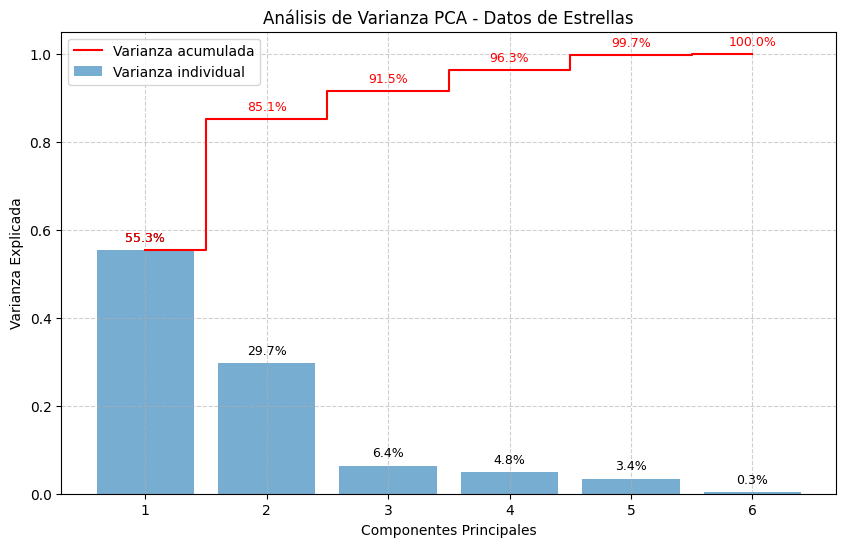

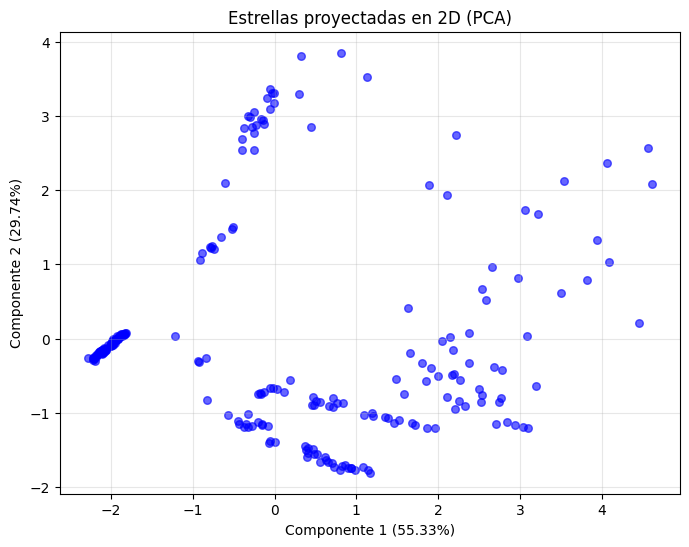

In [8]:
from sklearn.pipeline import Pipeline

# Preparamos los datos (X)
# Usamos las variables originales + las que hemos mapeado a números
features = ['Temperature', 'L', 'R', 'A_M', 'Rango_Color', 'Rango_Espectral']
X = df[features]

# Creamos el Pipeline 
# Paso 1: Escalar, Paso 2: PCA (sin número de componentes para ver todas primero)
pipeline_exploratorio = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

# Ajustamos y transformamos
X_pca_full = pipeline_exploratorio.fit_transform(X)
pca_step = pipeline_exploratorio.named_steps['pca']

# Visualizamos la varianza
varianza_explicada = pca_step.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, label='Varianza individual')
plt.step(range(1, len(varianza_acumulada) + 1), varianza_acumulada, where='mid', label='Varianza acumulada', color='red')

# Añadimos etiquetas de porcentaje y hacemos que se interprete mejor visualmente
for i, (ev, cv) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    plt.text(i + 1, ev + 0.02, f"{ev:.1%}", ha='center', fontsize=9)
    plt.text(i + 1, cv + 0.02, f"{cv:.1%}", ha='center', color='red', fontsize=9)

plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Análisis de Varianza PCA - Datos de Estrellas')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Ahora aplicamos la reducción a 2 componentes
pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=100522245)) # Semilla de NIA
])

X_reduced = pipeline_final.fit_transform(X)

# Guardamos el resultado en un DataFrame para el clustering posterior
df_pca_estrellas = pd.DataFrame(data=X_reduced, columns=['PC1', 'PC2'])

# Visualización final en 2D
plt.figure(figsize=(8, 6))
plt.scatter(df_pca_estrellas['PC1'], df_pca_estrellas['PC2'], alpha=0.6, c='blue', s=30)
plt.title('Estrellas proyectadas en 2D (PCA)')
plt.xlabel(f'Componente 1 ({varianza_explicada[0]:.2%})')
plt.ylabel(f'Componente 2 ({varianza_explicada[1]:.2%})')
plt.grid(True, alpha=0.3)
plt.show()

Para desarrollar **PCA**, primero creamos la matriz de datos **X**, que únicamente contiene las variables que vamos a usar en el modelo (ya que **Color** y **Spectral_Class** no las usamos al no ser numéricas). A continuación, construimos un **Pipeline** que primero escala con **StandardScaler** y después hacemos **PCA** sin especificar el número de componentes con el objetivo de observar cómo de importante es cada componente para explicar los datos (aunque se nos dice que debemos reducir a 2 dimensiones, creemos que es buena práctica observarlo primero). Después, entrenamos el pipeline y transformamos los datos y accedemos a **PCA**. Ahora, tomando ese objeto **PCA**, calculamos la **varianza explicada**, para ver cuánta información captura cada componente, y la **varianza acumulada**, para ver cuánta información va capturada en total. Una vez hecho esto, hacemos un gráfico para reconocer ese ***elbow*** que nos ayuda a decidir en que momento podemos dejar de añadir componentes porque no ayuda mucho. Como se puede observar en dicho gráfico, la **primera componente captura el 55,3%** y la **segunda componente el 29,7%**, elevando la **captura total al 85,1%**. La **tercera componente solo captura el 6,4%**, por lo que no creemos necesario incluirla, razón por la cual nuestro **PCA será de 2 dimensiones**, como dice el enunciado. Ahora ya podemos aplicar la **reducción a 2 componentes** en **PCA** (haciendo antes **StandardScaler** obviamente). Finalmente, guardamos el resultado (**PC1 y PC2**) en un nuevo **Dataframe** con el objetivo de usarlo posteriormente en clustering y, además, observamos esa transformación en 2 dimensiones con el objetivo de comprobar si se forman grupos (y efectivamente, observamos que sí, habiendo un grupo más a la izquierda, otro más abajo, otro arriba...). 

A continuación procederemos a aplicar los diferentes **algoritmos de clustering**:

## **APARTADO 3: ALGORITMOS DE CLUSTERING**

Comenzaramos este apartado llevando a cabo **K-Means**. En primer lugar, debemos decir el número **K** de clusters que queremos que haya. Para ello, implementamos el **Método del Codo** y el **Método Silhouette** con el objetivo de estar totalmente seguros del número de clusters que usaremos, pues veremos el número obtenido con ambos métodos:

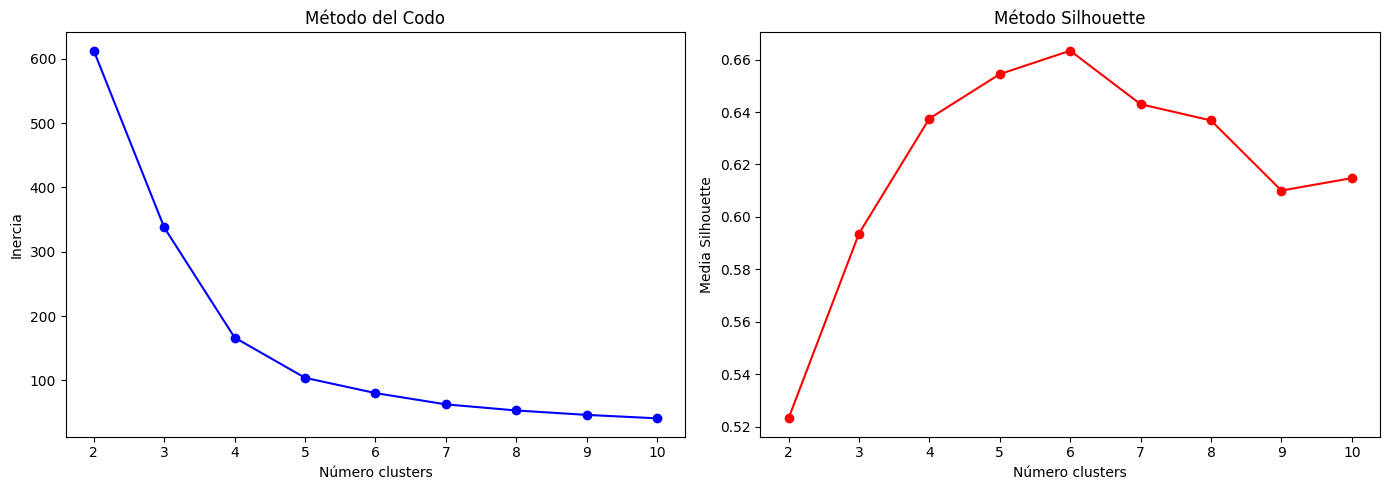

In [11]:
from sklearn.metrics import silhouette_score

# Usamos los datos del PCA
X_input = X_reduced

# Establecemos el número de clusters que queremos comprobar
range_n_clusters = range(2, 11)
inertias = []
silhouette_vals = []

# Entrenamos un modelo K-Means para cada número de clusters
for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
        n_clusters   = n_clusters,  # Número de clusters
        n_init       = 20,  # Prueba 20 veces y se queda con la mejor
        random_state = 100522245
    )
    
    # Aprende dónde están los centroides y asigna cada punto a un cluster
    labels = modelo_kmeans.fit_predict(X_input)
    
    # Guardamos métricas
    inertias.append(modelo_kmeans.inertia_)
    silhouette_vals.append(silhouette_score(X_input, labels))

# Visualizamos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del Codo
ax1.plot(range_n_clusters, inertias, marker='o', color='blue')
ax1.set_title("Método del Codo")
ax1.set_xlabel('Número clusters')
ax1.set_ylabel('Inercia')

# Gráfico de Silhouette
ax2.plot(range_n_clusters, silhouette_vals, marker='o', color='red')
ax2.set_title("Método Silhouette")
ax2.set_xlabel('Número clusters')
ax2.set_ylabel('Media Silhouette')

plt.tight_layout()
plt.show()

Para implementar ambos métodos usamos los datos del **PCA** y establecemos el rango en el que se moverá **K**. A continuación, entrenaremos **un modelo de K-Means para cada K** y lo iremos almacenando en **inertias o silhouette_vals**, para al final crear dos gráficos que muestren los resultados de ambos métodos. En el **Método del Codo** vemos un cambio de pendiente en **K=4**, **K=5** y **K=6**, algo que no nos deja claro que número de clusters escoger. No obstante, en el **Método Silhouette** el pico máximo está en **K=6**, por lo que **el número de clusters elegido es K=6**.